# Task 1 - Analysis

Student: s4239310  
Role: Senior Data Scientist, People Analytics (Commonwealth Bank, REQ259561)

Two publicly available workforce datasets analysed with two machine learning
algorithms: Random Forest and a Multi-layer Perceptron neural network.



## 0. Setup


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, recall_score)
from sklearn.metrics import accuracy_score, recall_score

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)


def recall_at(threshold):
    """Scorer measuring recall at a chosen decision threshold rather than 0.5."""
    def scorer(est, X, y):
        pred = (est.predict_proba(X)[:, 1] >= threshold).astype(int)
        return recall_score(y, pred)
    return scorer


Set `REPO` to your local clone path. The assertion stops execution if the path
is wrong rather than loading from somewhere unintended.


In [60]:
REPO = Path(r"E:\UNI\Semester2-2026\COSC2816-CaseStudies\cosc2816-individual-task1")
DATA = REPO / "data"
FIGS = REPO / "figures"
FIGS.mkdir(exist_ok=True)

assert DATA.exists(), f"Data folder not found: {DATA}"
print("Using:", DATA)


Using: E:\UNI\Semester2-2026\COSC2816-CaseStudies\cosc2816-individual-task1\data


---
# 1. Dataset A - IBM HR Employee Attrition

Source: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

Note: this is a fictional dataset created by IBM data scientists, not a real
workforce. This limits how far any finding can be generalised.

## 1.1 Load


In [61]:
hr = pd.read_csv(DATA / "WA_Fn-UseC_-HR-Employee-Attrition.csv", encoding="utf-8-sig")
hr.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 1.2 Explore


In [62]:
print('Rows, columns:', hr.shape)


Rows, columns: (1470, 35)


### Missing values


In [63]:
print('Total missing:', hr.isna().sum().sum())
print(hr.isna().sum()[hr.isna().sum() > 0])


Total missing: 0
Series([], dtype: int64)


`isna()` only detects real blanks. Missing data written as text (`?`, `NA`, `-`)
would be read as an ordinary category, so check for those separately.


In [64]:
placeholders = ['?', 'NA', 'N/A', '-', '', 'null', 'None', 'Unknown']
found = False
for c in hr.select_dtypes('object').columns:
    odd = [v for v in hr[c].unique() if str(v).strip() in placeholders]
    if odd:
        print(c, '->', odd)
        found = True
if not found:
    print('No placeholder-encoded missing values found.')


No placeholder-encoded missing values found.


### Target class balance


In [65]:
print(hr['Attrition'].value_counts())
print()
print(hr['Attrition'].value_counts(normalize=True).round(4) * 100)


Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


### Distinct value counts - identifying columns with no predictive value


In [66]:
print(hr.nunique().sort_values().head(10))


EmployeeCount        1
Over18               1
StandardHours        1
Attrition            2
OverTime             2
PerformanceRating    2
Gender               2
BusinessTravel       3
Department           3
MaritalStatus        3
dtype: int64


### Value ranges


In [67]:
print(hr.describe().round(2).to_string())


           Age  DailyRate  DistanceFromHome  Education  EmployeeCount  EmployeeNumber  EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  MonthlyRate  NumCompaniesWorked  PercentSalaryHike  PerformanceRating  RelationshipSatisfaction  StandardHours  StockOptionLevel  TotalWorkingYears  TrainingTimesLastYear  WorkLifeBalance  YearsAtCompany  YearsInCurrentRole  YearsSinceLastPromotion  YearsWithCurrManager
count  1470.00    1470.00           1470.00    1470.00         1470.0         1470.00                  1470.00     1470.00         1470.00   1470.00          1470.00        1470.00      1470.00             1470.00            1470.00            1470.00                   1470.00         1470.0           1470.00            1470.00                1470.00          1470.00         1470.00             1470.00                  1470.00               1470.00
mean     36.92     802.49              9.19       2.91            1.0         1024.87         

### Duplicate rows

`EmployeeNumber` is unique per row and masks duplicates, so check both ways.


In [68]:
print('duplicate rows:', hr.duplicated().sum())
print('ignoring EmployeeNumber:', hr.drop(columns='EmployeeNumber').duplicated().sum())


duplicate rows: 0
ignoring EmployeeNumber: 0


## 1.3 Clean and prepare

Here 3 of the columns have all rows identical, that means they don't have any
predictive value so I will drop those, and Employee ID as it also has no
predictive value.


In [69]:
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']

hr_clean = hr.drop(columns=drop_cols)
print('after dropping columns:', hr_clean.shape)


after dropping columns: (1470, 31)


### Target and features


In [70]:
y = hr_clean['Attrition'].map({'Yes': 1, 'No': 0})   # 1 = left
X = hr_clean.drop(columns='Attrition')

print('X shape:', X.shape)
print('y balance:', y.value_counts(normalize=True).round(3).to_dict())


X shape: (1470, 30)
y balance: {0: 0.839, 1: 0.161}


### Encoding text columns


In [71]:
cat_cols = X.select_dtypes('object').columns.tolist()
print(len(cat_cols), 'categorical:', cat_cols)


7 categorical: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [72]:
X_enc = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print('before:', X.shape, ' after:', X_enc.shape)


before: (1470, 30)  after: (1470, 44)


### Train / test split


In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print('train:', X_train.shape, ' test:', X_test.shape)
print('train attrition rate:', round(y_train.mean(), 3))
print('test  attrition rate:', round(y_test.mean(), 3))


train: (1176, 44)  test: (294, 44)
train attrition rate: 0.162
test  attrition rate: 0.16


## 1.4 Model 1 - Random Forest


In [74]:
rf = RandomForestClassifier(random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred, target_names=['Stayed', 'Left']))
print(confusion_matrix(y_test, rf_pred))


              precision    recall  f1-score   support

      Stayed       0.85      0.97      0.91       247
        Left       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294

[[240   7]
 [ 42   5]]


### Response to class imbalance - class weighting


In [75]:
rf_bal = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE)
rf_bal.fit(X_train, y_train)
rf_bal_pred = rf_bal.predict(X_test)

print(classification_report(y_test, rf_bal_pred, target_names=['Stayed', 'Left']))
print(confusion_matrix(y_test, rf_bal_pred))


              precision    recall  f1-score   support

      Stayed       0.88      0.93      0.90       247
        Left       0.47      0.32      0.38        47

    accuracy                           0.83       294
   macro avg       0.67      0.63      0.64       294
weighted avg       0.81      0.83      0.82       294

[[230  17]
 [ 32  15]]


### Response to class imbalance - decision threshold


In [76]:
probs = rf.predict_proba(X_test)[:, 1]

for t in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1]:
    pred = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) else 0
    print(f"threshold {t:.2f} | caught {tp:2d}/47 | false alarms {fp:3d} | flagged {tp+fp:3d} | recall {recall:.2f} | precision {precision:.2f}")


threshold 0.50 | caught  5/47 | false alarms   7 | flagged  12 | recall 0.11 | precision 0.42
threshold 0.40 | caught  9/47 | false alarms  10 | flagged  19 | recall 0.19 | precision 0.47
threshold 0.30 | caught 17/47 | false alarms  28 | flagged  45 | recall 0.36 | precision 0.38
threshold 0.25 | caught 28/47 | false alarms  40 | flagged  68 | recall 0.60 | precision 0.41
threshold 0.20 | caught 33/47 | false alarms  59 | flagged  92 | recall 0.70 | precision 0.36
threshold 0.15 | caught 38/47 | false alarms  99 | flagged 137 | recall 0.81 | precision 0.28
threshold 0.10 | caught 45/47 | false alarms 151 | flagged 196 | recall 0.96 | precision 0.23


At the default 0.5 it caught 5 of 47. Move the cutoff to 0.25 and the same model,
unchanged, catches 28 of 47. The default model performs poorly and the default
threshold is inappropriate for imbalanced data.

Limitation: this threshold was chosen by inspecting the test set, so 0.60 recall is
an optimistic estimate.


## 1.5 Model 2 - MLP neural network

MLP needs scaled features. The Pipeline fits the scaler on training data only.


In [77]:
mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=1000, random_state=RANDOM_STATE))
])
mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)

print(classification_report(y_test, mlp_pred, target_names=['Stayed', 'Left']))
print(confusion_matrix(y_test, mlp_pred))


              precision    recall  f1-score   support

      Stayed       0.88      0.91      0.89       247
        Left       0.42      0.34      0.38        47

    accuracy                           0.82       294
   macro avg       0.65      0.63      0.64       294
weighted avg       0.81      0.82      0.81       294

[[225  22]
 [ 31  16]]


### MLP decision threshold

Same sweep applied to the MLP, for a like-for-like comparison with Random Forest.


In [78]:
probs_mlp = mlp.predict_proba(X_test)[:, 1]
n_pos = y_test.sum()

for t in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1]:
    pred = (probs_mlp >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f"threshold {t:.2f} | caught {tp:3d}/{n_pos} | false alarms {fp:3d} | recall {tp/(tp+fn):.2f} | precision {tp/(tp+fp) if tp+fp else 0:.2f}")


threshold 0.50 | caught  16/47 | false alarms  22 | recall 0.34 | precision 0.42
threshold 0.40 | caught  18/47 | false alarms  24 | recall 0.38 | precision 0.43
threshold 0.30 | caught  18/47 | false alarms  25 | recall 0.38 | precision 0.42
threshold 0.25 | caught  19/47 | false alarms  28 | recall 0.40 | precision 0.40
threshold 0.20 | caught  20/47 | false alarms  32 | recall 0.43 | precision 0.38
threshold 0.15 | caught  23/47 | false alarms  33 | recall 0.49 | precision 0.41
threshold 0.10 | caught  25/47 | false alarms  37 | recall 0.53 | precision 0.40


## 1.6 Feature importance

Random Forest has a built-in `feature_importances_`; MLP does not. Permutation
importance is model-agnostic, so both rankings are measured the same way.


In [79]:
perm_rf = permutation_importance(rf, X_test, y_test, n_repeats=10,
                                 random_state=RANDOM_STATE, scoring='recall')

imp_rf = pd.Series(perm_rf.importances_mean, index=X_test.columns).sort_values(ascending=False)
print('RANDOM FOREST')
print(imp_rf.head(10).round(4))


RANDOM FOREST
MonthlyIncome                       0.0532
OverTime_Yes                        0.0383
TotalWorkingYears                   0.0191
JobLevel                            0.0170
Age                                 0.0085
BusinessTravel_Travel_Frequently    0.0064
YearsAtCompany                      0.0064
RelationshipSatisfaction            0.0021
HourlyRate                          0.0021
MonthlyRate                         0.0021
dtype: float64


In [80]:
perm_mlp = permutation_importance(mlp, X_test, y_test, n_repeats=10,
                                  random_state=RANDOM_STATE, scoring='recall')

imp_mlp = pd.Series(perm_mlp.importances_mean, index=X_test.columns).sort_values(ascending=False)
print('MLP')
print(imp_mlp.head(10).round(4))


MLP
OverTime_Yes                    0.1000
TotalWorkingYears               0.0574
YearsInCurrentRole              0.0511
YearsWithCurrManager            0.0489
JobRole_Sales Representative    0.0234
MonthlyIncome                   0.0191
EducationField_Life Sciences    0.0170
YearsAtCompany                  0.0149
DistanceFromHome                0.0128
PercentSalaryHike               0.0128
dtype: float64


### Importance measured at the chosen operating threshold

`permutation_importance` with `scoring='recall'` calls `predict()`, which always
uses a 0.5 cutoff. The rankings above were therefore measured on the model in its
default configuration - the one this analysis concluded was the wrong operating
point. Repeating the measurement at 0.25 checks whether the ranking survives.


In [81]:
perm_rf_25 = permutation_importance(rf, X_test, y_test, n_repeats=10,
                                   random_state=RANDOM_STATE,
                                   scoring=recall_at(0.25))

imp_rf_25 = pd.Series(perm_rf_25.importances_mean, index=X_test.columns).sort_values(ascending=False)
print('RANDOM FOREST - recall at threshold 0.25')
print(imp_rf_25.head(10).round(4))


RANDOM FOREST - recall at threshold 0.25
OverTime_Yes                0.1936
MonthlyRate                 0.0894
StockOptionLevel            0.0872
EnvironmentSatisfaction     0.0872
Age                         0.0766
MaritalStatus_Single        0.0702
JobLevel                    0.0447
DistanceFromHome            0.0447
RelationshipSatisfaction    0.0383
Department_Sales            0.0362
dtype: float64


In [82]:
compare_thresh = pd.DataFrame({
    'rank @0.50': imp_rf.rank(ascending=False).astype(int),
    'score @0.50': imp_rf.round(4),
    'rank @0.25': imp_rf_25.rank(ascending=False).astype(int),
    'score @0.25': imp_rf_25.round(4),
}).sort_values('rank @0.25').head(10)
compare_thresh


,rank @0.50,score @0.50,rank @0.25,score @0.25
OverTime_Yes,2,0.0383,1,0.1936
MonthlyRate,9,0.0021,2,0.0894
StockOptionLevel,41,-0.0128,3,0.0872
EnvironmentSatisfaction,26,-0.0021,4,0.0872
Age,5,0.0085,5,0.0766
MaritalStatus_Single,39,-0.0085,6,0.0702
JobLevel,4,0.0170,7,0.0447
DistanceFromHome,34,-0.0043,8,0.0447
RelationshipSatisfaction,9,0.0021,9,0.0383
Department_Sales,18,0.0000,10,0.0362


**MY OBSERVATION**

Feature importance is reported at threshold 0.25, since that is the operating
point this analysis selected. The 0.50 ranking was measured on a configuration
that was rejected, so it is retained only for comparison.

At 0.25, OverTime ranks first. At 0.50, MonthlyIncome ranked first.


### Follow-up: the shape of the career-stage effect

Importance says a feature matters, not the direction or shape of the effect.


Test whether the remaining features are separate things.

### Effect sizes for the other top features


In [83]:
print(hr.groupby('OverTime')['Attrition'].apply(lambda s: (s == 'Yes').mean()).round(3))
print()
print(hr.groupby('OverTime').size())


OverTime
No     0.104
Yes    0.305
Name: Attrition, dtype: float64

OverTime
No     1054
Yes     416
dtype: int64


In [84]:
inc = pd.qcut(hr['MonthlyIncome'], 5)
print(hr.groupby(inc, observed=True)['Attrition'].apply(lambda s: (s == 'Yes').mean()).round(3))


MonthlyIncome
(1008.999, 2695.8]    0.313
(2695.8, 4228.8]      0.170
(4228.8, 5743.4]      0.105
(5743.4, 9860.0]      0.126
(9860.0, 19999.0]     0.092
Name: Attrition, dtype: float64


### Correlation structure

Checking whether the top-ranked features are separate drivers or several
measurements of the same thing.


In [85]:
check = ['MonthlyIncome', 'TotalWorkingYears', 'JobLevel', 'Age', 'YearsAtCompany']
print(hr[check].corr().round(2).to_string())


                   MonthlyIncome  TotalWorkingYears  JobLevel   Age  YearsAtCompany
MonthlyIncome               1.00               0.77      0.95  0.50            0.51
TotalWorkingYears           0.77               1.00      0.78  0.68            0.63
JobLevel                    0.95               0.78      1.00  0.51            0.53
Age                         0.50               0.68      0.51  1.00            0.31
YearsAtCompany              0.51               0.63      0.53  0.31            1.00


In [86]:
ot = (hr['OverTime'] == 'Yes').astype(int)
for col in check:
    print('OverTime vs', col, ':', round(ot.corr(hr[col]), 3))


OverTime vs MonthlyIncome : 0.006
OverTime vs TotalWorkingYears : 0.013
OverTime vs JobLevel : 0.001
OverTime vs Age : 0.028
OverTime vs YearsAtCompany : -0.012


In [87]:
bins = pd.cut(hr['TotalWorkingYears'], bins=[-1, 2, 5, 10, 20, 40])

print(hr.groupby(bins, observed=True)['Attrition']
        .apply(lambda s: (s == 'Yes').mean()).round(3))
print()
print(hr.groupby(bins, observed=True).size())


TotalWorkingYears
(-1, 2]     0.439
(2, 5]      0.192
(5, 10]     0.150
(10, 20]    0.115
(20, 40]    0.077
Name: Attrition, dtype: float64

TotalWorkingYears
(-1, 2]     123
(2, 5]      193
(5, 10]     607
(10, 20]    340
(20, 40]    207
dtype: int64


### Visualisation - Dataset A

The dashed line is the overall attrition rate. Bars above it are higher-risk groups.


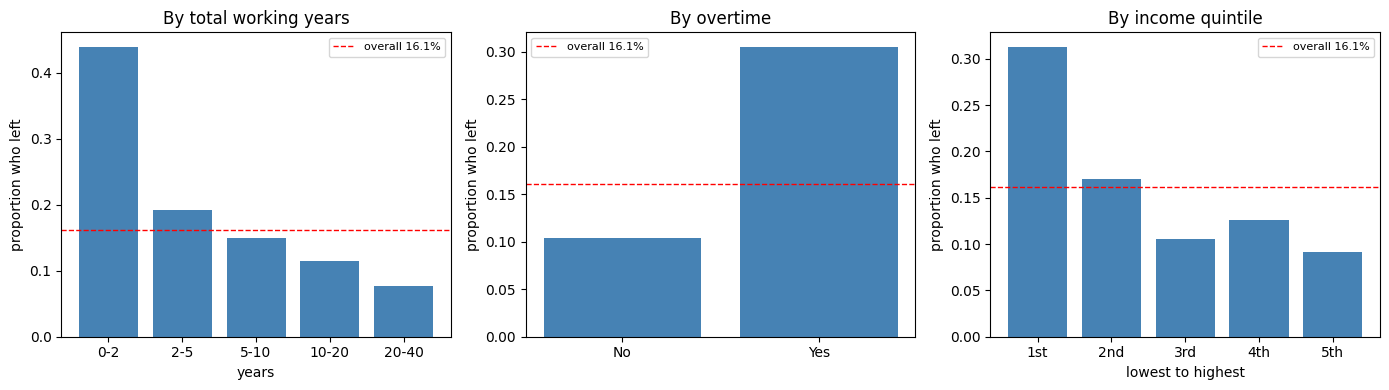

Red line marks the 16.1% company-wide rate


In [88]:
base_a = (hr['Attrition'] == 'Yes').mean()
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

bins = pd.cut(hr['TotalWorkingYears'], bins=[-1, 2, 5, 10, 20, 40])
r = hr.groupby(bins, observed=True)['Attrition'].apply(lambda s: (s == 'Yes').mean())
axes[0].bar(range(len(r)), r.values, color='steelblue')
axes[0].set_xticks(range(len(r)))
axes[0].set_xticklabels(['0-2', '2-5', '5-10', '10-20', '20-40'])
axes[0].set_title('By total working years'); axes[0].set_xlabel('years')

r = hr.groupby('OverTime')['Attrition'].apply(lambda s: (s == 'Yes').mean())
axes[1].bar(r.index, r.values, color='steelblue')
axes[1].set_title('By overtime')

inc = pd.qcut(hr['MonthlyIncome'], 5)
r = hr.groupby(inc, observed=True)['Attrition'].apply(lambda s: (s == 'Yes').mean())
axes[2].bar(range(len(r)), r.values, color='steelblue')
axes[2].set_xticks(range(len(r)))
axes[2].set_xticklabels(['1st', '2nd', '3rd', '4th', '5th'])
axes[2].set_title('By income quintile'); axes[2].set_xlabel('lowest to highest')

for ax in axes:
    ax.axhline(base_a, color='red', ls='--', lw=1, label=f'overall {base_a:.1%}')
    ax.set_ylabel('proportion who left'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / "dataset_a_drivers.png", dpi=150, bbox_inches='tight')
plt.show()
print ("Red line marks the 16.1% company-wide rate")

MY OBSERVATION: There graphs demonstrates that in this dataset that the who just started their career are at more risk to leave than the one already working for years, And the people working overtime leaves with high proportion then the one who doesnt work overtime, and the last factor is the people given lower salary appear to leave comapny at higher propotioin then the one earning more

### Conclusion - Dataset A

The drivers are:

- **MonthlyIncome** - ranked 1st by Random Forest at the default threshold, and
  in the top ten by MLP.
- **OverTime** - ranked 1st by Random Forest at the 0.25 operating threshold, and
  1st by MLP.
- **TotalWorkingYears** - third.

A ranking only tells us that a feature matters, not how much, so the actual
attrition rates were checked to confirm the effects were real: 43.9% against a
16.1% overall rate for early career, and 30.5% against 10.4% for overtime.
Neither is a modelling artefact.

MonthlyIncome, JobLevel and TotalWorkingYears are strongly correlated, so they
collapse into a single driver rather than counting as three. OverTime is
statistically independent of that group.


---
# 2. Dataset B - HR Analytics (employee turnover)

Source: https://www.kaggle.com/datasets/giripujar/hr-analytics

A second workforce dataset from a different organisation with the same target
concept: whether an employee left. The protocol from Dataset A is applied
unchanged, so the two sources can be compared directly.

## 2.1 Load


In [89]:
hr2 = pd.read_csv(DATA / 'HR_comma_sep.csv')
print('Rows, columns:', hr2.shape)
hr2.head()


Rows, columns: (14999, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [90]:
hr2.columns.tolist()


['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_montly_hours',
 'time_spend_company',
 'Work_accident',
 'left',
 'promotion_last_5years',
 'Department',
 'salary']

## 2.2 Explore

### Missing values


In [91]:
print('Total missing:', hr2.isna().sum().sum())
print(hr2.isna().sum()[hr2.isna().sum() > 0])


Total missing: 0
Series([], dtype: int64)


Same check as Dataset A - missing data written as text.


In [92]:
placeholders = ['?', 'NA', 'N/A', '-', '', 'null', 'None', 'Unknown']
found = False
for col in hr2.select_dtypes('object').columns:
    odd = [v for v in hr2[col].dropna().unique() if str(v).strip() in placeholders]
    if odd:
        print(col, '->', odd)
        found = True
if not found:
    print('No placeholder-encoded missing values found.')


No placeholder-encoded missing values found.


In [93]:
for col in hr2.select_dtypes('object').columns:
    print(col, ':', hr2[col].unique())


Department : ['sales' 'accounting' 'hr' 'technical' 'support' 'management' 'IT'
 'product_mng' 'marketing' 'RandD']
salary : ['low' 'medium' 'high']


### Target class balance


In [94]:
print(hr2['left'].value_counts())
print()
print(hr2['left'].value_counts(normalize=True).round(4) * 100)


left
0    11428
1     3571
Name: count, dtype: int64

left
0    76.19
1    23.81
Name: proportion, dtype: float64


### Distinct value counts

Looking for columns where every row is identical, or every row is different.


In [95]:
print(hr2.nunique().sort_values())


left                       2
promotion_last_5years      2
Work_accident              2
salary                     3
number_project             6
time_spend_company         8
Department                10
last_evaluation           65
satisfaction_level        92
average_montly_hours     215
dtype: int64


### Value ranges


In [96]:
print(hr2.describe().round(2).to_string())


       satisfaction_level  last_evaluation  number_project  average_montly_hours  time_spend_company  Work_accident      left  promotion_last_5years
count            14999.00         14999.00        14999.00              14999.00            14999.00       14999.00  14999.00               14999.00
mean                 0.61             0.72            3.80                201.05                3.50           0.14      0.24                   0.02
std                  0.25             0.17            1.23                 49.94                1.46           0.35      0.43                   0.14
min                  0.09             0.36            2.00                 96.00                2.00           0.00      0.00                   0.00
25%                  0.44             0.56            3.00                156.00                3.00           0.00      0.00                   0.00
50%                  0.64             0.72            4.00                200.00                3.00      

### Duplicate rows

Same check as applied to Dataset A.


In [97]:
print('duplicate rows:', hr2.duplicated().sum())
print('as % of data:', round(hr2.duplicated().mean() * 100, 1))


duplicate rows: 3008
as % of data: 20.1


### Duplicate rows




In [98]:
hr2 = hr2.drop_duplicates()
print('rows:', len(hr2))


rows: 11991


## 2.3 Clean and prepare

`salary` is a three-level band, not an amount.

**MY REASONING.** The same checks used on Dataset A were applied. No column had
a single distinct value, so nothing was zero-variance, and no column was unique
per row, so nothing was an identifier. Nothing qualified for dropping. The only
cleaning step required was removing duplicate rows.


In [99]:
y2 = hr2['left']                       # already 0/1, 1 = left
X2 = hr2.drop(columns='left')

print('X2 shape:', X2.shape)
print('y2 balance:', y2.value_counts(normalize=True).round(3).to_dict())


X2 shape: (11991, 9)
y2 balance: {0: 0.834, 1: 0.166}


### Encoding text columns


In [100]:
cat_cols2 = X2.select_dtypes('object').columns.tolist()
print(len(cat_cols2), 'categorical:', cat_cols2)


2 categorical: ['Department', 'salary']


In [101]:
X2_enc = pd.get_dummies(X2, columns=cat_cols2, drop_first=True)
print('before:', X2.shape, ' after:', X2_enc.shape)


before: (11991, 9)  after: (11991, 18)


### Train / test split

Stratified, 80/20, same random state as Dataset A.


In [102]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_enc, y2, test_size=0.2, stratify=y2, random_state=RANDOM_STATE)

print('train:', X2_train.shape, ' test:', X2_test.shape)
print('train leave rate:', round(y2_train.mean(), 3))
print('test  leave rate:', round(y2_test.mean(), 3))


train: (9592, 18)  test: (2399, 18)
train leave rate: 0.166
test  leave rate: 0.166


## 2.4 Model 1 - Random Forest


In [103]:
rf2 = RandomForestClassifier(random_state=RANDOM_STATE)
rf2.fit(X2_train, y2_train)
rf2_pred = rf2.predict(X2_test)

print(classification_report(y2_test, rf2_pred, target_names=['Stayed', 'Left']))
print(confusion_matrix(y2_test, rf2_pred))


              precision    recall  f1-score   support

      Stayed       0.99      1.00      0.99      2001
        Left       0.99      0.92      0.96       398

    accuracy                           0.99      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.99      0.99      0.99      2399

[[1997    4]
 [  30  368]]


Baseline: predicting the majority class for everyone.


In [104]:
print('naive baseline accuracy:', round(1 - y2_test.mean(), 3))

naive baseline accuracy: 0.834


### Response to class imbalance - class weighting


In [105]:
rf2_bal = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE)
rf2_bal.fit(X2_train, y2_train)
rf2_bal_pred = rf2_bal.predict(X2_test)

print(classification_report(y2_test, rf2_bal_pred, target_names=['Stayed', 'Left']))
print(confusion_matrix(y2_test, rf2_bal_pred))

              precision    recall  f1-score   support

      Stayed       0.98      1.00      0.99      2001
        Left       0.98      0.92      0.95       398

    accuracy                           0.98      2399
   macro avg       0.98      0.96      0.97      2399
weighted avg       0.98      0.98      0.98      2399

[[1993    8]
 [  31  367]]


### Response to class imbalance - decision threshold

Testing whether the pattern found on Dataset A holds here.


In [106]:
probs2 = rf2.predict_proba(X2_test)[:, 1]
n_pos = y2_test.sum()

for t in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1]:
    pred = (probs2 >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y2_test, pred).ravel()
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) else 0
    print(f"threshold {t:.2f} | caught {tp:4d}/{n_pos} | false alarms {fp:4d} | flagged {tp+fp:4d} | recall {recall:.2f} | precision {precision:.2f}")

threshold 0.50 | caught  368/398 | false alarms    4 | flagged  372 | recall 0.92 | precision 0.99
threshold 0.40 | caught  370/398 | false alarms    6 | flagged  376 | recall 0.93 | precision 0.98
threshold 0.30 | caught  370/398 | false alarms   11 | flagged  381 | recall 0.93 | precision 0.97
threshold 0.25 | caught  371/398 | false alarms   22 | flagged  393 | recall 0.93 | precision 0.94
threshold 0.20 | caught  373/398 | false alarms   35 | flagged  408 | recall 0.94 | precision 0.91
threshold 0.15 | caught  373/398 | false alarms   57 | flagged  430 | recall 0.94 | precision 0.87
threshold 0.10 | caught  374/398 | false alarms  133 | flagged  507 | recall 0.94 | precision 0.74


MY OBSERVATION: The default setting works fine here and lowering thethreshold is causing false alarms unlike Dataset A

## 2.5 Model 2 - MLP neural network


In [107]:
mlp2 = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=1000, random_state=RANDOM_STATE))
])
mlp2.fit(X2_train, y2_train)
mlp2_pred = mlp2.predict(X2_test)

print(classification_report(y2_test, mlp2_pred, target_names=['Stayed', 'Left']))
print(confusion_matrix(y2_test, mlp2_pred))


              precision    recall  f1-score   support

      Stayed       0.98      0.99      0.98      2001
        Left       0.92      0.89      0.91       398

    accuracy                           0.97      2399
   macro avg       0.95      0.94      0.95      2399
weighted avg       0.97      0.97      0.97      2399

[[1971   30]
 [  42  356]]


## 2.6 Feature importance

`n_repeats=5` rather than 10, since this dataset is larger.


In [108]:
perm_rf2 = permutation_importance(rf2, X2_test, y2_test, n_repeats=5,
                                  random_state=RANDOM_STATE, scoring='recall')

imp_rf2 = pd.Series(perm_rf2.importances_mean, index=X2_test.columns).sort_values(ascending=False)
print('RANDOM FOREST')
print(imp_rf2.head(10).round(4))


RANDOM FOREST
satisfaction_level       0.6945
number_project           0.4759
last_evaluation          0.4648
average_montly_hours     0.4492
time_spend_company       0.3367
salary_medium            0.0015
Work_accident            0.0010
Department_technical     0.0005
salary_low               0.0005
promotion_last_5years    0.0000
dtype: float64


In [109]:
perm_mlp2 = permutation_importance(mlp2, X2_test, y2_test, n_repeats=5,
                                   random_state=RANDOM_STATE, scoring='recall')

imp_mlp2 = pd.Series(perm_mlp2.importances_mean, index=X2_test.columns).sort_values(ascending=False)
print('MLP')
print(imp_mlp2.head(10).round(4))


MLP
number_project           0.6362
average_montly_hours     0.5392
satisfaction_level       0.5070
last_evaluation          0.4427
time_spend_company       0.4317
salary_low               0.0377
Department_sales         0.0342
salary_medium            0.0327
Department_support       0.0246
Department_management    0.0151
dtype: float64


### Follow-up: effect sizes

Actual leave rates within groups, for the features the models ranked highest.


In [110]:
# tenure
print(hr2.groupby('time_spend_company')['left'].mean().round(3))
print()
print(hr2.groupby('time_spend_company').size())


time_spend_company
2     0.011
3     0.168
4     0.247
5     0.454
6     0.201
7     0.000
8     0.000
10    0.000
Name: left, dtype: float64

time_spend_company
2     2910
3     5190
4     2005
5     1062
6      542
7       94
8       81
10     107
dtype: int64


In [111]:
# pay band
print(hr2.groupby('salary')['left'].mean().round(3))


salary
high      0.048
low       0.205
medium    0.146
Name: left, dtype: float64


In [112]:
# workload
hours = pd.qcut(hr2['average_montly_hours'], 5)
print(hr2.groupby(hours, observed=True)['left'].mean().round(3))


average_montly_hours
(95.999, 151.0]    0.260
(151.0, 182.0]     0.111
(182.0, 218.0]     0.019
(218.0, 251.0]     0.146
(251.0, 310.0]     0.297
Name: left, dtype: float64


### Correlation structure

Dataset A had three features that turned out to measure the same construct.
Same check before drawing conclusions here.


In [113]:
num_cols = hr2.select_dtypes('number').drop(columns='left').columns
print(hr2[num_cols].corr().round(2).to_string())


                       satisfaction_level  last_evaluation  number_project  average_montly_hours  time_spend_company  Work_accident  promotion_last_5years
satisfaction_level                   1.00             0.10           -0.13                 -0.01               -0.15           0.04                   0.02
last_evaluation                      0.10             1.00            0.27                  0.26                0.10          -0.01                  -0.01
number_project                      -0.13             0.27            1.00                  0.33                0.19          -0.01                  -0.00
average_montly_hours                -0.01             0.26            0.33                  1.00                0.10          -0.01                  -0.00
time_spend_company                  -0.15             0.10            0.19                  0.10                1.00           0.00                   0.06
Work_accident                        0.04            -0.01           -

### Visualisation - Dataset B

Same three concepts as Dataset A: tenure, workload and pay.


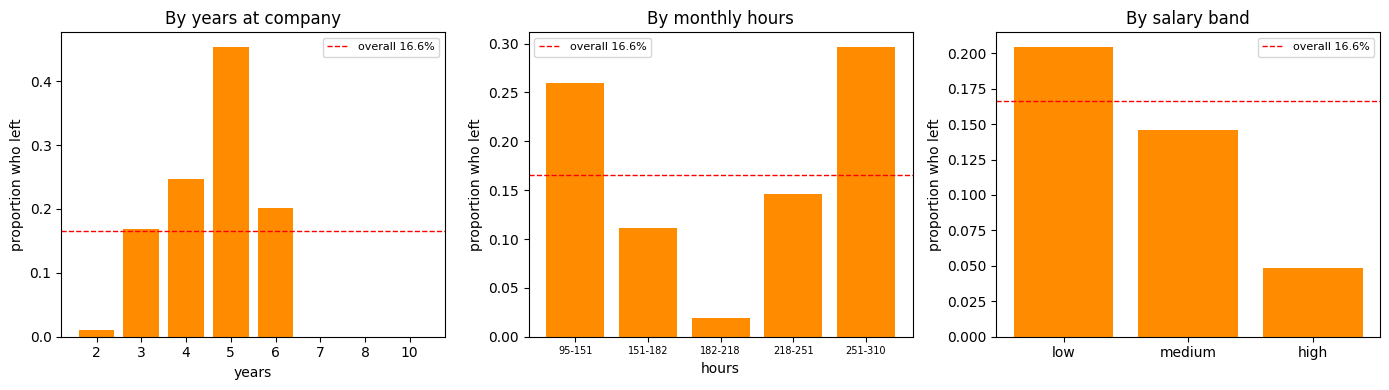

In [114]:
base_b = hr2['left'].mean()
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

r = hr2.groupby('time_spend_company')['left'].mean()
axes[0].bar(r.index.astype(str), r.values, color='darkorange')
axes[0].set_title('By years at company'); axes[0].set_xlabel('years')

hours = pd.qcut(hr2['average_montly_hours'], 5)
r = hr2.groupby(hours, observed=True)['left'].mean()
axes[1].bar(range(len(r)), r.values, color='darkorange')
axes[1].set_xticks(range(len(r)))
axes[1].set_xticklabels([f'{int(i.left)}-{int(i.right)}' for i in r.index], fontsize=7)
axes[1].set_title('By monthly hours'); axes[1].set_xlabel('hours')

r = hr2.groupby('salary')['left'].mean().reindex(['low', 'medium', 'high'])
axes[2].bar(r.index, r.values, color='darkorange')
axes[2].set_title('By salary band')

for ax in axes:
    ax.axhline(base_b, color='red', ls='--', lw=1, label=f'overall {base_b:.1%}')
    ax.set_ylabel('proportion who left'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / "dataset_b_drivers.png", dpi=150, bbox_inches='tight')
plt.show()


**MY OBSERVATION**

The threshold sweep was run here because it was run on Dataset A, and both
datasets had to be treated identically for the comparison to hold. It worked
in the opposite direction on this dataset: the default 0.50 already performs
well, and lowering the threshold only adds false alarms. The default setting
is kept.


### Conclusion - Dataset B

The main drivers are:

- **number_project** - number of projects assigned. Ranked 1st by MLP and 2nd by
  Random Forest.
- **satisfaction_level** - ranked 1st by Random Forest and 3rd by MLP.
- **time_spend_company** - years at the company.

Both models select the same five features and then drop sharply, so the
membership of the group is not in doubt even though the ordering differs.

Unlike Dataset A, pay and department fall below that cliff and the features are
largely independent of one another, so these are separate drivers rather than
one construct measured several ways.


---
# 3. Comparison across both datasets

Only features measuring the same construct are compared. `TotalWorkingYears` in
Dataset A is total career experience, not tenure at the employer, so
`YearsAtCompany` is the correct counterpart to `time_spend_company`.

`OverTime` and `average_montly_hours` are deliberately **not** compared. One is a
yes/no flag and the other a continuous count; they can be compared in direction
but not in shape, and Dataset A has no continuous hours column.

The two companies have different overall attrition rates, so raw percentages are
not comparable. Dividing each group's rate by its own dataset's base rate puts
both on the same scale: 1.0 is average risk, 2.0 is twice average.


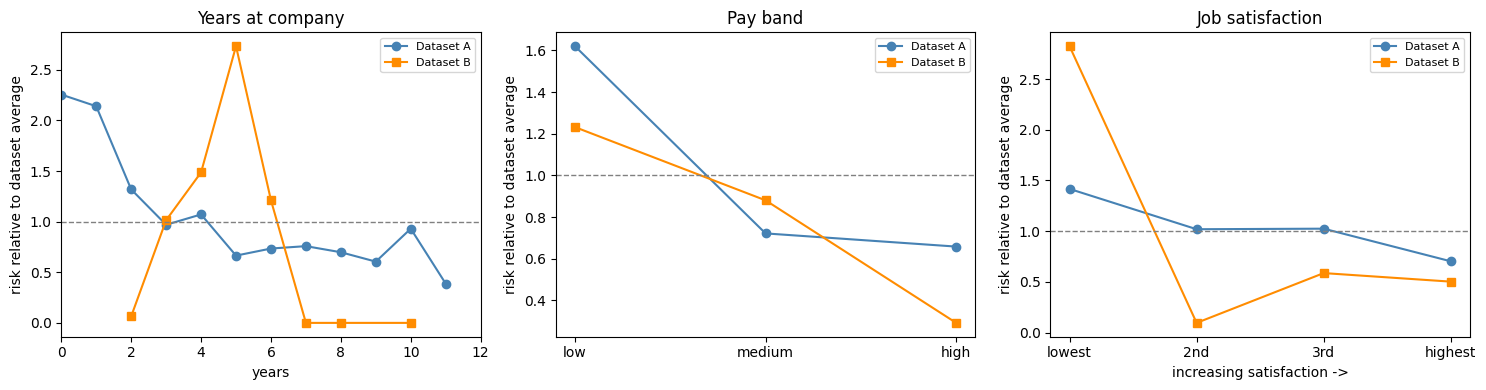

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Tenure at the company: YearsAtCompany vs time_spend_company ---
a = hr.groupby('YearsAtCompany')['Attrition'].apply(lambda s: (s == 'Yes').mean())
a_n = hr.groupby('YearsAtCompany').size()
b = hr2.groupby('time_spend_company')['left'].mean()
b_n = hr2.groupby('time_spend_company').size()

a = a[a_n >= 30]; b = b[b_n >= 30]   # drop groups too small to read

axes[0].plot(a.index, a.values / base_a, 'o-', label='Dataset A', color='steelblue')
axes[0].plot(b.index, b.values / base_b, 's-', label='Dataset B', color='darkorange')
axes[0].set_title('Years at company'); axes[0].set_xlabel('years'); axes[0].set_xlim(0, 12)

# --- Pay: terciles in both, so the bands are comparable ---
a = hr.groupby(pd.qcut(hr['MonthlyIncome'], 3, labels=['low', 'medium', 'high']),
               observed=True)['Attrition'].apply(lambda s: (s == 'Yes').mean())
b = hr2.groupby('salary')['left'].mean().reindex(['low', 'medium', 'high'])
axes[1].plot(range(3), a.values / base_a, 'o-', label='Dataset A', color='steelblue')
axes[1].plot(range(3), b.values / base_b, 's-', label='Dataset B', color='darkorange')
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(['low', 'medium', 'high'])
axes[1].set_title('Pay band')

# --- Satisfaction: A is 1-4, B is 0-1, so compare as quartiles ---
a = hr.groupby('JobSatisfaction')['Attrition'].apply(lambda s: (s == 'Yes').mean())
b = hr2.groupby(pd.qcut(hr2['satisfaction_level'], 4, labels=[1, 2, 3, 4]),
                observed=True)['left'].mean()
axes[2].plot(range(4), a.values / base_a, 'o-', label='Dataset A', color='steelblue')
axes[2].plot(range(4), b.values / base_b, 's-', label='Dataset B', color='darkorange')
axes[2].set_xticks(range(4)); axes[2].set_xticklabels(['lowest', '2nd', '3rd', 'highest'])
axes[2].set_title('Job satisfaction'); axes[2].set_xlabel('increasing satisfaction ->')

for ax in axes:
    ax.axhline(1.0, color='grey', ls='--', lw=1)
    ax.set_ylabel('risk relative to dataset average'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / "comparison_a_vs_b.png", dpi=150, bbox_inches="tight")
plt.show()


### Model performance side by side


In [116]:
rf_tuned_a  = (rf.predict_proba(X_test)[:, 1]   >= 0.25).astype(int)
rf_tuned_b  = (rf2.predict_proba(X2_test)[:, 1] >= 0.25).astype(int)

summary = pd.DataFrame({
    'Dataset A (IBM HR)': [
        len(hr_clean),
        round(y.mean(), 3),
        round(1 - y_test.mean(), 3),
        round(accuracy_score(y_test, rf_pred), 3),
        round(recall_score(y_test, rf_pred), 3),
        round(recall_score(y_test, rf_tuned_a), 3),
        round(accuracy_score(y_test, mlp_pred), 3),
        round(recall_score(y_test, mlp_pred), 3),
    ],
    'Dataset B (HR Analytics)': [
        len(hr2),
        round(y2.mean(), 3),
        round(1 - y2_test.mean(), 3),
        round(accuracy_score(y2_test, rf2_pred), 3),
        round(recall_score(y2_test, rf2_pred), 3),
        round(recall_score(y2_test, rf_tuned_b), 3),
        round(accuracy_score(y2_test, mlp2_pred), 3),
        round(recall_score(y2_test, mlp2_pred), 3),
    ],
}, index=['rows after cleaning', 'minority class rate', 'naive baseline accuracy',
          'RF accuracy', 'RF recall @0.50', 'RF recall @0.25',
          'MLP accuracy', 'MLP recall @0.50'])

summary


,Dataset A (IBM HR),Dataset B (HR Analytics)
rows after cleaning,1470.000,11991.000
minority class rate,0.161,0.166
naive baseline accuracy,0.840,0.834
RF accuracy,0.833,0.986
RF recall @0.50,0.106,0.925
RF recall @0.25,0.596,0.932
MLP accuracy,0.820,0.970
MLP recall @0.50,0.340,0.894




The algorithms identified which features predict leaving, and how those features
rank against each other. Changing the decision threshold changed both the
performance and the ranking, so the insight depends on the operating point
chosen, not on the algorithm alone.

Both produced insights, but not of equal quality. Dataset A is fictional data,
which makes its insights doubtful. Dataset B produced clearer results, though
its near-perfect separability suggests it may also be simulated.

Insights are mainly complementary. Dataset B surfaced additional features worth noting, and supported several of the features already found in Dataset A.


---
# 4. Process notes - issues encountered

1. `ModuleNotFoundError: No module named 'sklearn'`. pandas and matplotlib imported
   without error, so the kernel was correct but scikit-learn was not installed in that
   environment. Resolved by installing it into the kernel with `%pip install
   scikit-learn`, then restarting. That cell has since been removed so the notebook
   runs clean; the package is listed in `requirements.txt`.

2. First `drop_cols` run omitted `EmployeeNumber`, giving 31 columns rather than the
   expected 30. Caught by checking the shape against the expected count.

3. Relative data paths failed. `os.getcwd()` returned the home directory rather than
   the repository, so no relative path could resolve. A fallback searching several
   candidate folders then matched an unrelated `Data` directory in the home folder and
   loaded silently from the wrong place. Resolved with an absolute `REPO` constant plus
   an assertion, so a wrong path halts execution instead of failing quietly. Figure
   saving was later switched from relative paths to `FIGS` for the same reason.

4. `class_weight='balanced'` did not resolve the imbalance on either dataset, for
   opposite reasons. On Dataset A the model was ignoring the minority class and
   weighting could not fix it, because the constraint was the 0.5 voting threshold
   rather than how the trees were built. On Dataset B the model was not ignoring the
   minority class, so there was nothing for weighting to correct. Class weighting is
   therefore not an automatic remedy for imbalance.

5. The duplicate check was initially applied to Dataset B only. Adding it to Dataset A
   was necessary for the two datasets to have had identical treatment. Dataset A
   contained no duplicates; Dataset B contained 3,008.

6. Removing 3,008 duplicates from Dataset B shifted its class balance from 23.8% to
   16.6%, showing the duplicated rows were disproportionately leavers. This also brought
   the two datasets to almost the same class balance, which removed imbalance as an
   explanation for their very different model performance.

7. Small-sample caution: in Dataset B the 7, 8 and 10-year tenure groups contain 94, 81
   and 107 employees and all show a leave rate of exactly 0.000. Group sizes are
   annotated on the comparison chart and these bands are treated as too small to
   support a conclusion.

8. Both datasets are suspected to be synthetic. IBM state theirs is fictional, and
   Dataset B's near-perfect separability is not characteristic of real workforce data.
   This limits how far any finding here generalises to a real workforce.

9. Permutation importance was initially computed with `scoring='recall'`, which
   calls `predict()` and therefore uses the default 0.5 threshold. For Dataset A
   this measured feature importance on a model with recall 0.11 - the
   configuration the analysis had already rejected - so the absolute values were
   compressed and the ranking was drawn from an operating point not being used.
   Repeated at the selected threshold of 0.25 for comparison. Dataset B is
   unaffected, since 0.5 was already its chosen operating point.

